   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income ocean_proximity  median_house_value  
0         322         126         8.3252        NEAR BAY              452600  
1        2401        1138         8.3014        NEAR BAY              358500  
2         496         177         7.2574        NEAR BAY              352100  
3         558         219         5.6431        NEAR BAY              341300  
4         565         259         3.8462        NEAR BAY              342200  
(20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries

C:\Users\tanis\AppData\Local\Temp\ipykernel_13980\890882000.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


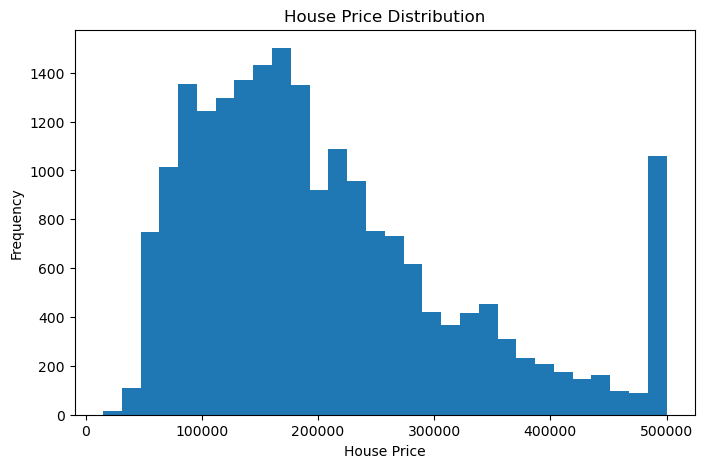

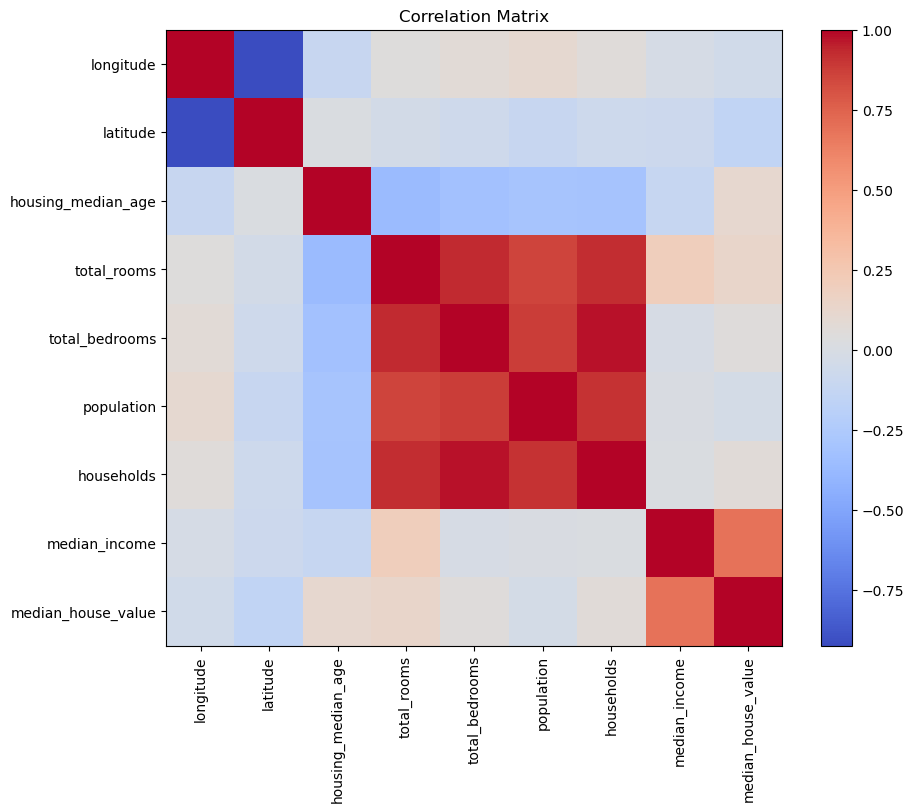

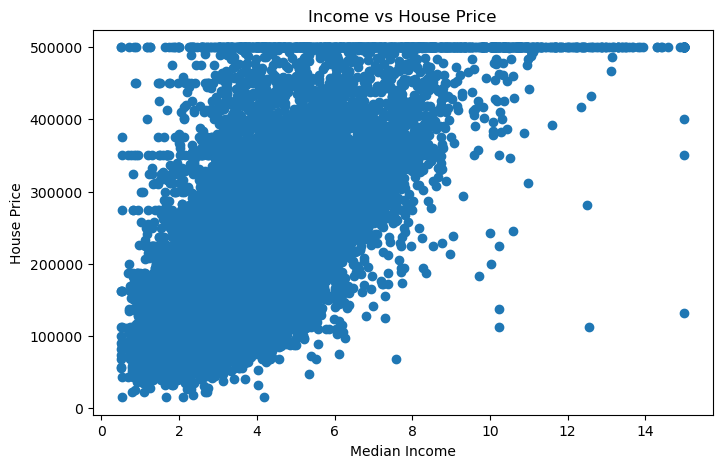

MAE: 50670.73824097188
RMSE: 70060.521844735
R2 Score: 0.6254240620553624


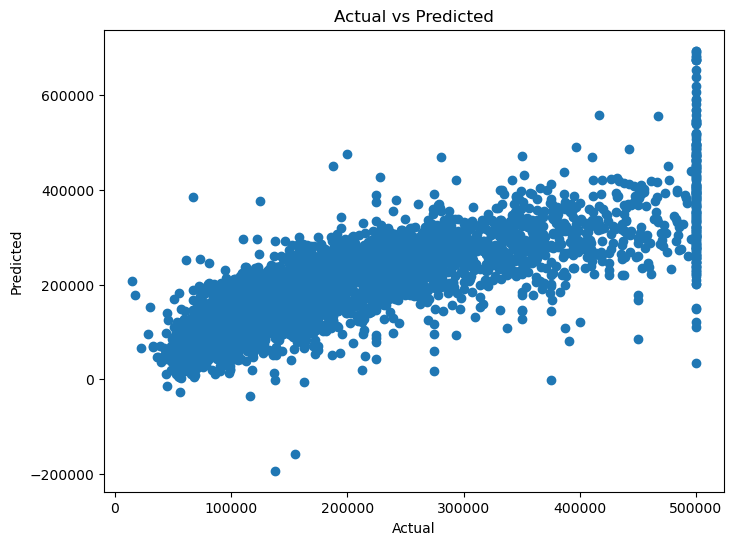

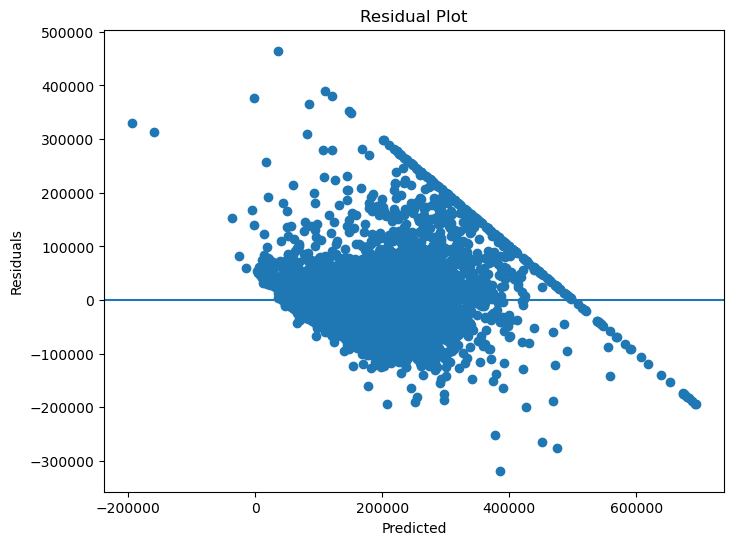

                       Feature    Coefficient
9       ocean_proximity_ISLAND  136125.072615
7                median_income   39473.975175
11  ocean_proximity_NEAR OCEAN    3431.140073
2           housing_median_age    1102.185084
4               total_bedrooms     102.789395
6                   households      48.252753
3                  total_rooms      -6.021506
5                   population     -38.172906
10    ocean_proximity_NEAR BAY   -5136.642217
1                     latitude  -25468.352050
0                    longitude  -26838.273372
8       ocean_proximity_INLAND  -39786.656161


In [22]:
# importing libraries such as pandas, nnumpy, matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


# Loading the dataset from kaggle , placing it into the folder where our code is being executed

df = pd.read_csv("housing.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())


# Fill missing values

df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


# House price distribution

plt.figure(figsize=(8,5))
plt.hist(df["median_house_value"], bins=30)
plt.title("House Price Distribution")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()


# Correlation heatmap

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()


# Income vs price ( for the graph)

plt.figure(figsize=(8,5))
plt.scatter(
    df["median_income"],
    df["median_house_value"]
)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Income vs House Price")
plt.show()


df = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)



X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]


# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# linear regression model is being used

model = LinearRegression()
model.fit(X_train, y_train)


# Predict

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


# Actual vs predicted graph

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


# Residual plot graph

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


# Feature coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(
    by="Coefficient",
    ascending=False
))


